In [26]:
import random
import time
import cProfile
import pstats
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve)

random.seed(123)
np.random.seed(123)

In [27]:
# Cargar el dataset directamente desde el archivo RData con pyreadr
contenido_rdata = pyreadr.read_r("listings.RData")
listings = contenido_rdata["listings"]

print("Dimensiones originales:", listings.shape)
listings.head()
##

Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [28]:
# Limpiar precio (quitar $ y comas), forzar columnas numericas, eliminar NA y outliers (p99)
listings["precio_num"] = (
    listings["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
)
listings["precio_num"] = pd.to_numeric(listings["precio_num"], errors="coerce")

columnas_modelo = ["precio_num", "accommodates", "bathrooms", "bedrooms", "beds",
                   "minimum_nights", "number_of_reviews", "review_scores_rating",
                   "availability_365", "reviews_per_month"]

datos = listings[columnas_modelo].copy()
# pyreadr devuelve algunas columnas como object, hay que forzarlas a numerico
for col in columnas_modelo:
    datos[col] = pd.to_numeric(datos[col], errors="coerce")

datos = datos.dropna()
datos = datos[datos["precio_num"] > 0]
limite_precio = datos["precio_num"].quantile(0.99)
datos = datos[datos["precio_num"] <= limite_precio].reset_index(drop=True)

print("Dimensiones despues de limpieza:", datos.shape)
datos["precio_num"].describe() ## 

Dimensiones despues de limpieza: (62095, 10)


count    62095.000000
mean       258.341767
std        257.958774
min          8.000000
25%        116.000000
50%        181.000000
75%        297.000000
max       2112.000000
Name: precio_num, dtype: float64

In [29]:
# PUNTO 1: variable categorica de precio (economica / media / cara) usando terciles
datos["categoria_precio"] = pd.qcut(
    datos["precio_num"], q=3, labels=["economica", "media", "cara"]
)

# Tres variables dicotomicas solicitadas (valores 0 y 1)
datos["es_cara"]      = (datos["categoria_precio"] == "cara").astype(int)
datos["es_media"]     = (datos["categoria_precio"] == "media").astype(int)
datos["es_economica"] = (datos["categoria_precio"] == "economica").astype(int)

print("Frecuencia por categoria:")
print(datos["categoria_precio"].value_counts())
print("\nProporciones:")
print(datos["categoria_precio"].value_counts(normalize=True).round(3))
datos[["precio_num", "categoria_precio", "es_cara", "es_media", "es_economica"]].head() ##

Frecuencia por categoria:
categoria_precio
economica    20937
cara         20644
media        20514
Name: count, dtype: int64

Proporciones:
categoria_precio
economica    0.337
cara         0.332
media        0.330
Name: proportion, dtype: float64


,precio_num,categoria_precio,es_cara,es_media,es_economica
0,97.0,economica,0,0,1
1,160.0,media,0,1,0
2,38.0,economica,0,0,1
3,145.0,media,0,1,0
4,58.0,economica,0,0,1


In [30]:
predictores = ["accommodates", "bathrooms", "bedrooms", "beds",
               "minimum_nights", "number_of_reviews", "review_scores_rating",
               "availability_365", "reviews_per_month"]

X = datos[predictores]
y = datos["es_cara"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, train_size=0.7,
    random_state=123, stratify=datos["categoria_precio"]
)

print("Entrenamiento:", X_train.shape, " Prueba:", X_test.shape)
print("Proporcion es_cara train:", round(y_train.mean(), 4))
print("Proporcion es_cara test: ", round(y_test.mean(), 4))

Entrenamiento: (43466, 9)  Prueba: (18629, 9)
Proporcion es_cara train: 0.3324
Proporcion es_cara test:  0.3325


In [31]:
X_train.info()
X_train.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
Index: 43466 entries, 39896 to 22056
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accommodates          43466 non-null  int32  
 1   bathrooms             43466 non-null  float64
 2   bedrooms              43466 non-null  float64
 3   beds                  43466 non-null  float64
 4   minimum_nights        43466 non-null  int32  
 5   number_of_reviews     43466 non-null  int32  
 6   review_scores_rating  43466 non-null  float64
 7   availability_365      43466 non-null  int32  
 8   reviews_per_month     43466 non-null  float64
dtypes: float64(5), int32(4)
memory usage: 2.7 MB


,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365,reviews_per_month
count,43466.00,43466.00,43466.00,43466.00,43466.00,43466.00,43466.00,43466.00,43466.00
mean,4.77,1.57,1.77,2.64,7.49,66.23,4.80,229.45,1.58
std,2.88,0.86,1.28,1.94,17.13,102.45,0.33,105.20,1.70
min,1.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.01
25%,2.00,1.00,1.00,1.00,1.00,7.00,4.75,152.00,0.33
50%,4.00,1.00,1.00,2.00,2.00,27.00,4.89,253.00,1.04
75%,6.00,2.00,2.00,3.00,4.00,82.00,5.00,323.00,2.37
max,16.00,13.00,48.00,37.00,365.00,1462.00,5.00,365.00,61.59


In [32]:
modelo_logistico = LogisticRegression(solver="liblinear", max_iter=1000, random_state=123)
cv_estratificada = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

accuracy_cv = cross_val_score(modelo_logistico, X_train, y_train, cv=cv_estratificada, scoring="accuracy")
auc_cv      = cross_val_score(modelo_logistico, X_train, y_train, cv=cv_estratificada, scoring="roc_auc")

modelo_logistico.fit(X_train, y_train)

print("Accuracy media CV:", round(accuracy_cv.mean(), 4), "+-", round(accuracy_cv.std(), 4))
print("AUC media CV:     ", round(auc_cv.mean(), 4),      "+-", round(auc_cv.std(), 4))
coeficientes = pd.DataFrame({"variable": predictores, "coeficiente": modelo_logistico.coef_[0]})
print("\nCoeficientes sklearn:\n", coeficientes)

Accuracy media CV: 0.7893 +- 0.0052
AUC media CV:      0.8356 +- 0.007

Coeficientes sklearn:
                variable  coeficiente
0          accommodates     0.192722
1             bathrooms     0.682372
2              bedrooms     0.178735
3                  beds     0.103953
4        minimum_nights    -0.018719
5     number_of_reviews    -0.000070
6  review_scores_rating     0.607577
7      availability_365    -0.000559
8     reviews_per_month    -0.397917


In [33]:
X_train_sm = sm.add_constant(X_train)
modelo_sm = sm.Logit(y_train, X_train_sm).fit(disp=False)
print(modelo_sm.summary())

tabla_coeficientes = modelo_sm.summary2().tables[1].sort_values("P>|z|")
print("\nVariables ordenadas por p-value (mas significativas primero):")
print(tabla_coeficientes)

                           Logit Regression Results                           
Dep. Variable:                es_cara   No. Observations:                43466
Model:                          Logit   Df Residuals:                    43456
Method:                           MLE   Df Model:                            9
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.2674
Time:                        12:59:20   Log-Likelihood:                -20248.
converged:                       True   LL-Null:                       -27640.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -6.1031      0.234    -26.129      0.000      -6.561      -5.645
accommodates             0.1951      0.011     18.222      0.000       0.174       0.216
bathrooms   

In [34]:
X_vif = sm.add_constant(X_train)
vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif.round(3))
print("\nRegla: VIF > 5 = multicolinealidad moderada, VIF > 10 = severa.")

               variable      VIF
0                 const  233.403
1          accommodates    5.249
2             bathrooms    2.356
3              bedrooms    4.022
4                  beds    4.214
5        minimum_nights    1.073
6     number_of_reviews    1.593
7  review_scores_rating    1.031
8      availability_365    1.017
9     reviews_per_month    1.656

Regla: VIF > 5 = multicolinealidad moderada, VIF > 10 = severa.


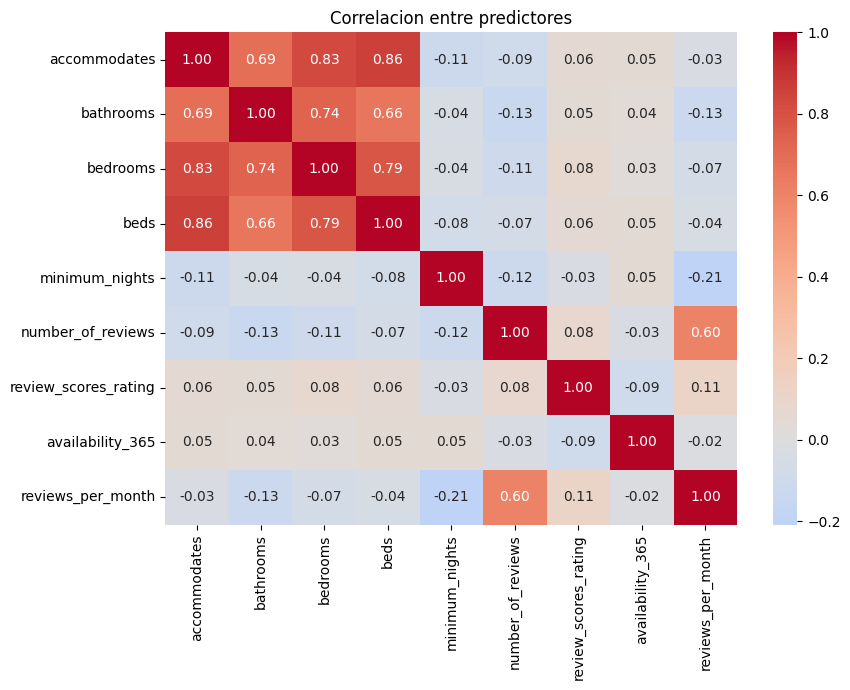

In [35]:
matriz_correlacion = X_train.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlacion entre predictores")
plt.tight_layout()
plt.show()

In [36]:
pseudo_r2_mcfadden = 1 - (modelo_sm.llf / modelo_sm.llnull)
print("Pseudo R2 McFadden:", round(pseudo_r2_mcfadden, 4))
print("Log-Likelihood:    ", round(modelo_sm.llf, 2))
print("AIC:               ", round(modelo_sm.aic, 2))
print("BIC:               ", round(modelo_sm.bic, 2))

Pseudo R2 McFadden: 0.2674
Log-Likelihood:     -20248.02
AIC:                40516.04
BIC:                40602.84


In [37]:
probabilidades_train = modelo_logistico.predict_proba(X_train)[:, 1]
predicciones_train   = (probabilidades_train >= 0.5).astype(int)

cm_train = confusion_matrix(y_train, predicciones_train)
print("Matriz de confusion (entrenamiento):\n", cm_train)
print("\nReporte de clasificacion (entrenamiento):")
print(classification_report(y_train, predicciones_train, target_names=["no_cara", "cara"]))

Matriz de confusion (entrenamiento):
 [[26012  3004]
 [ 6168  8282]]

Reporte de clasificacion (entrenamiento):
              precision    recall  f1-score   support

     no_cara       0.81      0.90      0.85     29016
        cara       0.73      0.57      0.64     14450

    accuracy                           0.79     43466
   macro avg       0.77      0.73      0.75     43466
weighted avg       0.78      0.79      0.78     43466



In [38]:
# PUNTO 5: eficiencia del modelo sobre el conjunto de prueba con umbral 0.5
probabilidades_test = modelo_logistico.predict_proba(X_test)[:, 1]
predicciones_test   = (probabilidades_test >= 0.5).astype(int)

cm_test = confusion_matrix(y_test, predicciones_test)
print("Matriz de confusion (prueba):\n", cm_test)
print("\nAccuracy: ", round(accuracy_score(y_test, predicciones_test), 4))
print("Precision:", round(precision_score(y_test, predicciones_test), 4))
print("Recall:   ", round(recall_score(y_test, predicciones_test), 4))
print("F1:       ", round(f1_score(y_test, predicciones_test), 4))
print("\nReporte de clasificacion (prueba):")
print(classification_report(y_test, predicciones_test, target_names=["no_cara", "cara"]))

Matriz de confusion (prueba):
 [[11148  1287]
 [ 2554  3640]]

Accuracy:  0.7938
Precision: 0.7388
Recall:    0.5877
F1:        0.6546

Reporte de clasificacion (prueba):
              precision    recall  f1-score   support

     no_cara       0.81      0.90      0.85     12435
        cara       0.74      0.59      0.65      6194

    accuracy                           0.79     18629
   macro avg       0.78      0.74      0.75     18629
weighted avg       0.79      0.79      0.79     18629



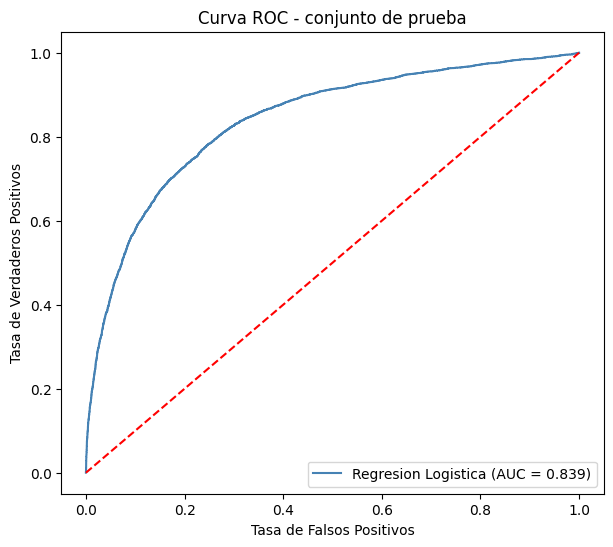

AUC en prueba: 0.8394


In [39]:
# Curva ROC y AUC sobre el conjunto de prueba
auc_test = roc_auc_score(y_test, probabilidades_test)
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Regresion Logistica (AUC = {auc_test:.3f})", color="steelblue")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - conjunto de prueba")
plt.legend(loc="lower right")
plt.show()
print("AUC en prueba:", round(auc_test, 4))

In [40]:
# PUNTO 6a: comparar errores de entrenamiento y prueba para detectar sobreajuste
error_train = 1 - accuracy_score(y_train, predicciones_train)
error_test  = 1 - accuracy_score(y_test,  predicciones_test)

print("Error de entrenamiento:", round(error_train, 4))
print("Error de prueba:       ", round(error_test, 4))
print("Diferencia test - train:", round(error_test - error_train, 4))
print("\nSi la diferencia es pequena no hay sobreajuste evidente.")
print("Si el error de train es mucho menor que el de test, hay overfitting.")

Error de entrenamiento: 0.211
Error de prueba:        0.2062
Diferencia test - train: -0.0048

Si la diferencia es pequena no hay sobreajuste evidente.
Si el error de train es mucho menor que el de test, hay overfitting.


In [41]:
# PUNTO 6b: curvas de aprendizaje usando error de train vs validacion
tamanos, scores_train, scores_val = learning_curve(
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=123),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring="accuracy", random_state=123, n_jobs=-1
)

errores_train = 1 - scores_train.mean(axis=1)
errores_val   = 1 - scores_val.mean(axis=1)
tabla_curva   = pd.DataFrame({"tamano": tamanos,
                              "error_entrenamiento": errores_train.round(4),
                              "error_validacion":    errores_val.round(4)})
print(tabla_curva)

   tamano  error_entrenamiento  error_validacion
0    3477               0.2139            0.2108
1    6954               0.2109            0.2114
2   10431               0.2108            0.2111
3   13908               0.2106            0.2110
4   17386               0.2118            0.2107
5   20863               0.2118            0.2106
6   24340               0.2109            0.2107
7   27817               0.2113            0.2109
8   31294               0.2109            0.2112
9   34772               0.2109            0.2113


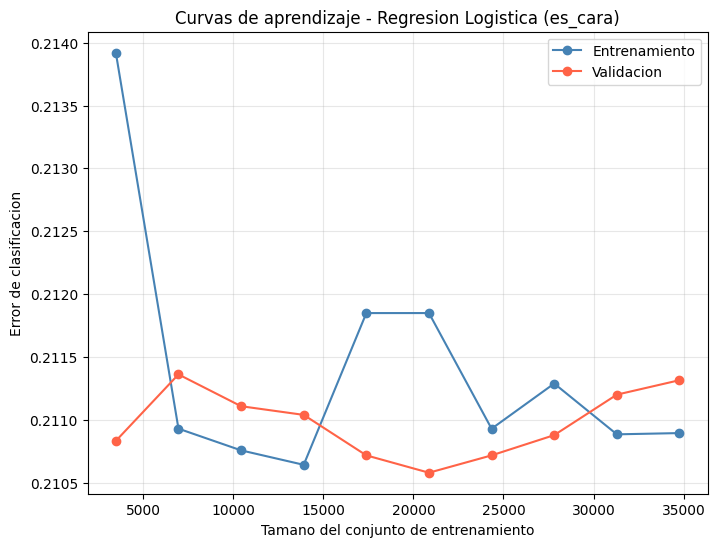

In [42]:
# Graficar las curvas de aprendizaje
plt.figure(figsize=(8, 6))
plt.plot(tamanos, errores_train, "o-", color="steelblue", label="Entrenamiento")
plt.plot(tamanos, errores_val,   "o-", color="tomato",    label="Validacion")
plt.xlabel("Tamano del conjunto de entrenamiento")
plt.ylabel("Error de clasificacion")
plt.title("Curvas de aprendizaje - Regresion Logistica (es_cara)")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

In [43]:
# PUNTO 7: tuneo con regularizacion (L1, L2) y varios valores de C usando GridSearchCV
grid_parametros = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
busqueda = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=123),
    param_grid=grid_parametros, cv=cv_estratificada, scoring="roc_auc", n_jobs=-1
)
busqueda.fit(X_train, y_train)

print("Mejor combinacion de hiperparametros:", busqueda.best_params_)
print("Mejor AUC en CV:", round(busqueda.best_score_, 4))
resultados_grid = pd.DataFrame(busqueda.cv_results_)[
    ["param_C", "param_penalty", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False)
print(resultados_grid.to_string(index=False))

Mejor combinacion de hiperparametros: {'C': 10.0, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor AUC en CV: 0.8356
 param_C param_penalty  mean_test_score  std_test_score
   10.00            l2         0.835583        0.003910
    1.00            l2         0.835548        0.003915
  100.00            l1         0.835512        0.003932
   10.00            l1         0.835510        0.003931
    1.00            l1         0.835502        0.003934
    0.10            l1         0.835310        0.003935
  100.00            l2         0.835235        0.003959
    0.10            l2         0.834549        0.004040
    0.01            l1         0.831018        0.004087
    0.01            l2         0.829578        0.004107


In [44]:
# Modelo tuneado + modelo base (sin tuneo) 
modelo_tuneado = busqueda.best_estimator_
modelo_base    = LogisticRegression(solver="liblinear", max_iter=1000, random_state=123).fit(X_train, y_train)

prob_tuneado_test = modelo_tuneado.predict_proba(X_test)[:, 1]
prob_base_test    = modelo_base.predict_proba(X_test)[:, 1]
pred_tuneado_05   = (prob_tuneado_test >= 0.5).astype(int)
pred_base_05      = (prob_base_test >= 0.5).astype(int)

print("AUC modelo base:    ", round(roc_auc_score(y_test, prob_base_test), 4))
print("AUC modelo tuneado: ", round(roc_auc_score(y_test, prob_tuneado_test), 4))
print("Acc modelo base:    ", round(accuracy_score(y_test, pred_base_05), 4))
print("Acc modelo tuneado: ", round(accuracy_score(y_test, pred_tuneado_05), 4))

AUC modelo base:     0.8394
AUC modelo tuneado:  0.8394
Acc modelo base:     0.7938
Acc modelo tuneado:  0.7938
